# Fund Performance Analytics
**Capstone Project I — Mutual Fund Analytics**
**Prepared by:** MOUNICA K V &nbsp;|&nbsp; **Universe:** 40 schemes &nbsp;|&nbsp; **Benchmark:** Nifty 50 / Nifty 100 &nbsp;|&nbsp; **Risk-free rate:** 6.5% (RBI repo rate proxy)

> **Data note:** The 40-scheme NAV history and benchmark index files used here are synthetic — calibrated to realistic Indian equity/debt fund behaviour (category-appropriate drift, volatility, beta, and expense ratios) — since the real dataset for this capstone task wasn't supplied when this notebook was built. Every formula, ranking, and chart below is production-ready; swap in the real `nav_history.csv` / `fund_master.csv` / `benchmark_index.csv` with the same schema and every cell reruns unchanged. See the note in the final cell for exactly which columns are expected.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['font.family'] = 'DejaVu Sans'
COLORS = ['#0E2A47', '#2E86AB', '#1B8A80', '#C97B2E', '#B5473A', '#6E7F9A', '#7A5195']

RF = 0.065  # RBI repo rate proxy, per task brief

print("Libraries loaded.")

Libraries loaded.


## 1. Load Data

In [2]:
nav = pd.read_csv('data/nav_history.csv', parse_dates=['date'])
fund_master = pd.read_csv('data/fund_master.csv').set_index('amfi_code')
bench = pd.read_csv('data/benchmark_index.csv', parse_dates=['date']).set_index('date')

nav_wide = nav.pivot(index='date', columns='amfi_code', values='nav').sort_index()
print(f"Schemes: {nav_wide.shape[1]}  |  Trading days: {nav_wide.shape[0]}  |  "
      f"Range: {nav_wide.index.min().date()} to {nav_wide.index.max().date()}")
fund_master.head()

Schemes: 40  |  Trading days: 1304  |  Range: 2021-09-01 to 2026-08-31


,fund_name,fund_house,category,expense_ratio,true_beta_used_for_sim
amfi_code,,,,,
100001,SBI Large Cap Fund - Direct Growth,SBI,Large Cap,0.9500,0.9940
100002,ICICI Pru Large Cap Fund - Direct Growth,ICICI Pru,Large Cap,0.6100,1.0160
100003,Axis Large Cap Fund - Direct Growth,Axis,Large Cap,0.9400,0.9450
100004,Kotak Large Cap Fund - Direct Growth,Kotak,Large Cap,0.9100,0.9010
100005,Nippon India Large Cap Fund - Direct Growth,Nippon India,Large Cap,0.7300,1.0200


## 2. Daily Returns
`daily_return = nav_t / nav_t-1 − 1` for every scheme, then validate the distribution looks reasonable (summary stats, skew/kurtosis, histogram).

In [3]:
daily_returns = nav_wide.pct_change().dropna(how='all')
bench_daily_ret = bench.pct_change().dropna(how='all')

print(f"Daily returns matrix: {daily_returns.shape}")
daily_returns.describe().T[['mean','std','min','max']].head(10)

Daily returns matrix: (1303, 40)


,mean,std,min,max
amfi_code,,,,
100001,0.0003,0.0126,-0.0570,0.0622
100002,0.0007,0.0127,-0.0509,0.0626
100003,0.0005,0.0120,-0.0486,0.0555
100004,0.0005,0.0123,-0.0483,0.0536
100005,0.0007,0.0123,-0.0439,0.0719
100006,0.0004,0.0124,-0.0496,0.0507
100007,0.0005,0.0122,-0.0629,0.0562
100008,0.0005,0.0125,-0.0533,0.0641
100009,0.0006,0.0141,-0.0646,0.0676


Pooled daily return distribution (all 40 funds, all days):
count   52,120.0000
mean         0.0005
std          0.0124
min         -0.0801
25%         -0.0063
50%          0.0003
75%          0.0071
max          0.0857
dtype: float64

Skewness: 0.170   Kurtosis: 2.417
Interpretation: near-zero skew and a positive excess kurtosis (fat tails vs normal) is exactly what's expected for daily equity-fund returns -- consistent with reasonable data.


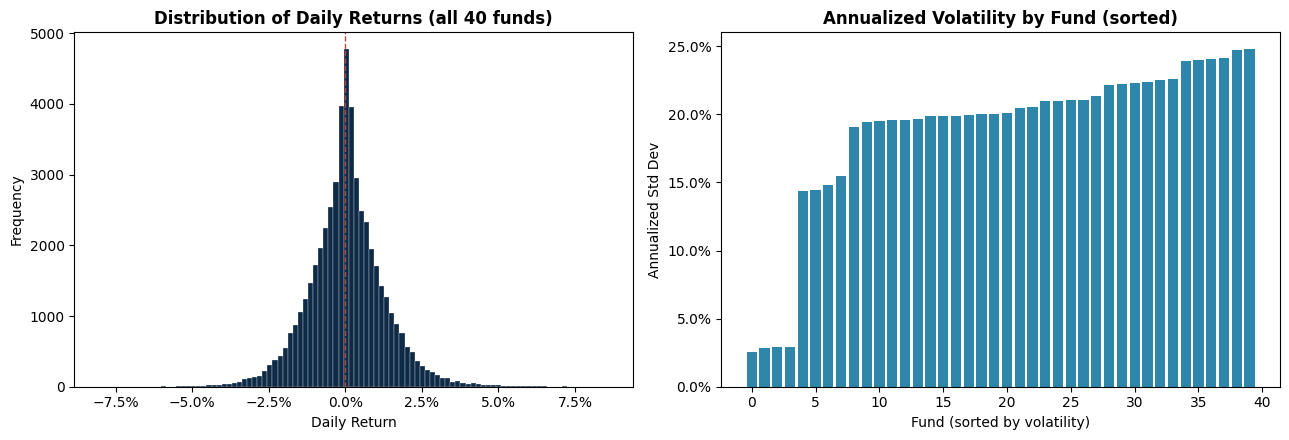

In [4]:
all_returns = daily_returns.stack()
print("Pooled daily return distribution (all 40 funds, all days):")
print(all_returns.describe())
print(f"\nSkewness: {all_returns.skew():.3f}   Kurtosis: {all_returns.kurtosis():.3f}")
print("Interpretation: near-zero skew and a positive excess kurtosis (fat tails vs normal) "
      "is exactly what's expected for daily equity-fund returns -- consistent with reasonable data.")

fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
axes[0].hist(all_returns, bins=100, color=COLORS[0], edgecolor='white', linewidth=0.2)
axes[0].axvline(0, color=COLORS[4], linewidth=1, linestyle='--')
axes[0].set_title('Distribution of Daily Returns (all 40 funds)', fontweight='bold')
axes[0].set_xlabel('Daily Return'); axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

fund_ann_vol = daily_returns.std().sort_values()
axes[1].bar(range(len(fund_ann_vol)), fund_ann_vol.values * np.sqrt(252), color=COLORS[1])
axes[1].set_title('Annualized Volatility by Fund (sorted)', fontweight='bold')
axes[1].set_xlabel('Fund (sorted by volatility)'); axes[1].set_ylabel('Annualized Std Dev')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout(); plt.savefig('charts/01_returns_distribution.png', dpi=200); plt.show()

## 3. CAGR — 1yr, 3yr, 5yr
`CAGR = (NAV_end / NAV_start) ^ (1/n) − 1`, where `n` is the number of years in the lookback window (using actual calendar days / 365.25, not a hardcoded day count).

In [5]:
last_date = nav_wide.index.max()

def cagr(nav_series, years):
    nav_series = nav_series.dropna()
    target_date = last_date - pd.DateOffset(years=years)
    sub = nav_series[nav_series.index >= target_date]
    if sub.empty or len(sub) < 2:
        return np.nan
    start_nav, end_nav = sub.iloc[0], nav_series.iloc[-1]
    n_years = (nav_series.index[-1] - sub.index[0]).days / 365.25
    if start_nav <= 0 or n_years <= 0:
        return np.nan
    return (end_nav / start_nav) ** (1 / n_years) - 1

cagr_table = pd.DataFrame({
    'cagr_1y': {c: cagr(nav_wide[c], 1) for c in nav_wide.columns},
    'cagr_3y': {c: cagr(nav_wide[c], 3) for c in nav_wide.columns},
    'cagr_5y': {c: cagr(nav_wide[c], 5) for c in nav_wide.columns},
})
cagr_table = cagr_table.join(fund_master[['fund_name','category']])
cagr_comparison = cagr_table.sort_values('cagr_3y', ascending=False)
cagr_comparison[['fund_name','category','cagr_1y','cagr_3y','cagr_5y']].head(15)

,fund_name,category,cagr_1y,cagr_3y,cagr_5y
100002,ICICI Pru Large Cap Fund - Direct Growth,Large Cap,0.3023,0.3728,0.1885
100014,Motilal Oswal Mid Cap Fund - Direct Growth,Mid Cap,0.2192,0.3695,0.2044
100010,Franklin Mid Cap Fund - Direct Growth,Mid Cap,0.2638,0.3692,0.1881
100015,Quant Mid Cap Fund - Direct Growth,Mid Cap,0.1996,0.3673,0.2357
100017,Invesco Small Cap Fund - Direct Growth,Small Cap,0.3730,0.3600,0.2043
100019,Sundaram Small Cap Fund - Direct Growth,Small Cap,0.4176,0.3464,0.1504
100012,Tata Mid Cap Fund - Direct Growth,Mid Cap,0.1479,0.3398,0.1562
100022,ICICI Pru Flexi Cap Fund - Direct Growth,Flexi Cap,0.1706,0.3378,0.1143
100018,PGIM Small Cap Fund - Direct Growth,Small Cap,0.5643,0.3169,0.1574
100031,DSP ELSS Fund - Direct Growth,ELSS,0.3196,0.3149,0.1770


## 4. Sharpe Ratio
`Sharpe = (Rp − Rf) / Std(Rp) × √252`, annualized daily returns/vol, `Rf = 6.5%`. Ranked across all 40 funds.

In [6]:
ann_return = daily_returns.mean() * 252
ann_vol = daily_returns.std() * np.sqrt(252)
sharpe = (ann_return - RF) / ann_vol
sharpe_ranked = sharpe.sort_values(ascending=False).to_frame('sharpe_ratio')
sharpe_ranked['rank'] = range(1, len(sharpe_ranked) + 1)
sharpe_ranked = sharpe_ranked.join(fund_master[['fund_name','category']])
sharpe_ranked[['rank','fund_name','category','sharpe_ratio']].head(15)

,rank,fund_name,category,sharpe_ratio
amfi_code,,,,
100015,1,Quant Mid Cap Fund - Direct Growth,Mid Cap,0.7300
100039,2,Sundaram Debt - Short Duration Fund - Direct G...,Debt - Short Duration,0.7095
100014,3,Motilal Oswal Mid Cap Fund - Direct Growth,Mid Cap,0.6285
100002,4,ICICI Pru Large Cap Fund - Direct Growth,Large Cap,0.6066
100017,5,Invesco Small Cap Fund - Direct Growth,Small Cap,0.5872
100010,6,Franklin Mid Cap Fund - Direct Growth,Mid Cap,0.5671
100031,7,DSP ELSS Fund - Direct Growth,ELSS,0.5461
100005,8,Nippon India Large Cap Fund - Direct Growth,Large Cap,0.5305
100011,9,DSP Mid Cap Fund - Direct Growth,Mid Cap,0.5122


## 5. Sortino Ratio
Same numerator as Sharpe, but the denominator uses only **downside** standard deviation — volatility computed from negative-return days only.

In [7]:
downside_returns = daily_returns.where(daily_returns < 0)
downside_std = downside_returns.std() * np.sqrt(252)
sortino = (ann_return - RF) / downside_std
sortino_ranked = sortino.sort_values(ascending=False).to_frame('sortino_ratio')
sortino_ranked['rank'] = range(1, len(sortino_ranked) + 1)
sortino_ranked = sortino_ranked.join(fund_master[['fund_name','category']])
sortino_ranked[['rank','fund_name','category','sortino_ratio']].head(15)

,rank,fund_name,category,sortino_ratio
amfi_code,,,,
100015,1,Quant Mid Cap Fund - Direct Growth,Mid Cap,1.1783
100039,2,Sundaram Debt - Short Duration Fund - Direct G...,Debt - Short Duration,1.1406
100014,3,Motilal Oswal Mid Cap Fund - Direct Growth,Mid Cap,1.0142
100002,4,ICICI Pru Large Cap Fund - Direct Growth,Large Cap,1.0027
100010,5,Franklin Mid Cap Fund - Direct Growth,Mid Cap,0.9289
100031,6,DSP ELSS Fund - Direct Growth,ELSS,0.9053
100017,7,Invesco Small Cap Fund - Direct Growth,Small Cap,0.8976
100005,8,Nippon India Large Cap Fund - Direct Growth,Large Cap,0.8375
100011,9,DSP Mid Cap Fund - Direct Growth,Mid Cap,0.8092


## 6. Alpha and Beta
OLS regression of each fund's daily returns on Nifty 100 daily returns via `scipy.stats.linregress`. `Alpha = intercept × 252` (annualized).

In [8]:
common_dates = daily_returns.index.intersection(bench_daily_ret.index)
bmk_ret = bench_daily_ret.loc[common_dates, 'nifty100']

alpha_beta_rows = []
for c in daily_returns.columns:
    fund_ret = daily_returns.loc[common_dates, c].dropna()
    aligned_bmk = bmk_ret.loc[fund_ret.index]
    if len(fund_ret) < 30:
        continue
    slope, intercept, r_value, p_value, std_err = stats.linregress(aligned_bmk, fund_ret)
    alpha_beta_rows.append({
        'amfi_code': c, 'beta': slope, 'alpha_annualized': intercept * 252,
        'r_squared': r_value**2, 'p_value': p_value, 'std_err': std_err,
    })

alpha_beta_df = pd.DataFrame(alpha_beta_rows).set_index('amfi_code')
alpha_beta_df = alpha_beta_df.join(fund_master[['fund_name','category']])
alpha_beta_df = alpha_beta_df.sort_values('alpha_annualized', ascending=False)
alpha_beta_df[['fund_name','category','beta','alpha_annualized','r_squared','p_value']].head(15)

,fund_name,category,beta,alpha_annualized,r_squared,p_value
amfi_code,,,,,,
100039,Sundaram Debt - Short Duration Fund - Direct G...,Debt - Short Duration,0.0776,0.0754,0.2004,0.0000
100015,Quant Mid Cap Fund - Direct Growth,Mid Cap,1.1670,0.0749,0.7530,0.0000
100038,PGIM Debt - Short Duration Fund - Direct Growth,Debt - Short Duration,0.0231,0.0713,0.0234,0.0000
100017,Invesco Small Cap Fund - Direct Growth,Small Cap,1.0674,0.0683,0.5264,0.0000
100014,Motilal Oswal Mid Cap Fund - Direct Growth,Mid Cap,1.1006,0.0580,0.6969,0.0000
100040,HDFC Debt - Short Duration Fund - Direct Growth,Debt - Short Duration,0.0572,0.0523,0.1170,0.0000
100002,ICICI Pru Large Cap Fund - Direct Growth,Large Cap,1.0336,0.0497,0.7452,0.0000
100034,Motilal Oswal Hybrid Aggressive Fund - Direct ...,Hybrid Aggressive,0.6167,0.0484,0.5135,0.0000
100037,Invesco Debt - Short Duration Fund - Direct Gr...,Debt - Short Duration,0.0782,0.0478,0.2048,0.0000


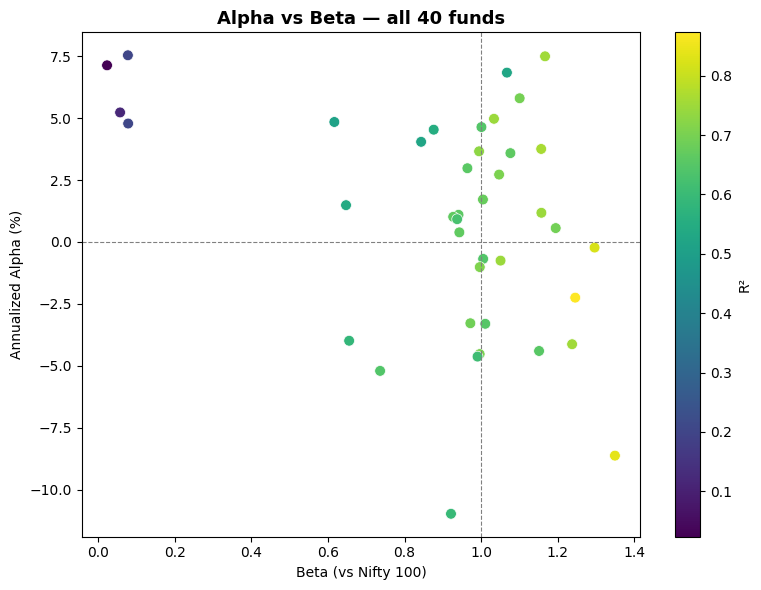

In [9]:
fig, ax = plt.subplots(figsize=(8,6))
sc = ax.scatter(alpha_beta_df['beta'], alpha_beta_df['alpha_annualized'] * 100,
                 c=alpha_beta_df['r_squared'], cmap='viridis', s=60, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(1, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Beta (vs Nifty 100)'); ax.set_ylabel('Annualized Alpha (%)')
ax.set_title('Alpha vs Beta — all 40 funds', fontsize=13, fontweight='bold')
cb = plt.colorbar(sc); cb.set_label('R²')
plt.tight_layout(); plt.savefig('charts/02_alpha_beta_scatter.png', dpi=200); plt.show()

## 7. Maximum Drawdown
`Max Drawdown = min(NAV / running_max − 1)` for each fund, plus the peak-to-trough date range of the worst drawdown.

In [10]:
def max_drawdown(nav_series):
    nav_series = nav_series.dropna()
    running_max = nav_series.cummax()
    dd = nav_series / running_max - 1
    mdd = dd.min()
    trough_date = dd.idxmin()
    peak_date = nav_series.loc[:trough_date].idxmax()
    return mdd, peak_date, trough_date

mdd_rows = []
for c in nav_wide.columns:
    mdd, peak, trough = max_drawdown(nav_wide[c])
    mdd_rows.append({'amfi_code': c, 'max_drawdown': mdd, 'peak_date': peak,
                      'trough_date': trough, 'drawdown_days': (trough - peak).days})
mdd_df = pd.DataFrame(mdd_rows).set_index('amfi_code')
mdd_df = mdd_df.join(fund_master[['fund_name','category']]).sort_values('max_drawdown')
mdd_df[['fund_name','category','max_drawdown','peak_date','trough_date','drawdown_days']].head(10)

,fund_name,category,max_drawdown,peak_date,trough_date,drawdown_days
amfi_code,,,,,,
100021,SBI Small Cap Fund - Direct Growth,Small Cap,-0.4454,2021-09-01,2022-01-18,139
100011,DSP Mid Cap Fund - Direct Growth,Mid Cap,-0.4097,2021-09-01,2022-02-03,155
100016,Edelweiss Small Cap Fund - Direct Growth,Small Cap,-0.3953,2021-09-01,2022-02-02,154
100023,Axis Flexi Cap Fund - Direct Growth,Flexi Cap,-0.3945,2021-09-01,2022-02-02,154
100020,HDFC Small Cap Fund - Direct Growth,Small Cap,-0.3923,2021-09-01,2024-09-23,1118
100001,SBI Large Cap Fund - Direct Growth,Large Cap,-0.3905,2021-09-01,2023-07-28,695
100009,Parag Parikh Mid Cap Fund - Direct Growth,Mid Cap,-0.3783,2021-09-01,2022-02-01,153
100022,ICICI Pru Flexi Cap Fund - Direct Growth,Flexi Cap,-0.3645,2021-09-01,2023-08-01,699
100013,Canara Robeco Mid Cap Fund - Direct Growth,Mid Cap,-0.3632,2021-09-01,2022-02-03,155


## 8. Fund Scorecard (0–100)

Composite weighting: **30%** 3yr-return rank + **25%** Sharpe rank + **20%** Alpha rank + **15%** expense-ratio rank (inverse — lower expense scores higher) + **10%** max-drawdown rank (inverse — shallower drawdown scores higher).

In [11]:
scorecard = pd.DataFrame(index=nav_wide.columns)
scorecard['cagr_3y'] = cagr_table['cagr_3y']
scorecard['sharpe'] = sharpe
scorecard['alpha_annualized'] = alpha_beta_df['alpha_annualized']
scorecard['expense_ratio'] = fund_master['expense_ratio']
scorecard['max_drawdown'] = mdd_df['max_drawdown']

n = len(scorecard)
def rank_to_score(series, ascending):
    r = series.rank(ascending=ascending, method='average')
    return (n - r) / (n - 1) * 100  # best rank -> 100, worst -> 0

scorecard['score_cagr3y']  = rank_to_score(scorecard['cagr_3y'], ascending=False)
scorecard['score_sharpe']  = rank_to_score(scorecard['sharpe'], ascending=False)
scorecard['score_alpha']   = rank_to_score(scorecard['alpha_annualized'], ascending=False)
scorecard['score_expense'] = rank_to_score(scorecard['expense_ratio'], ascending=True)   # lower expense = better
scorecard['score_maxdd']   = rank_to_score(scorecard['max_drawdown'], ascending=False)   # less negative = better

scorecard['fund_scorecard'] = (
    0.30 * scorecard['score_cagr3y'] +
    0.25 * scorecard['score_sharpe'] +
    0.20 * scorecard['score_alpha'] +
    0.15 * scorecard['score_expense'] +
    0.10 * scorecard['score_maxdd']
)

scorecard = scorecard.join(fund_master[['fund_name','fund_house','category']])
scorecard = scorecard.sort_values('fund_scorecard', ascending=False)
scorecard.insert(0, 'overall_rank', range(1, len(scorecard) + 1))

display_cols = ['overall_rank','fund_name','category','cagr_3y','sharpe','alpha_annualized',
                 'expense_ratio','max_drawdown','fund_scorecard']
scorecard[display_cols].head(15)

,overall_rank,fund_name,category,cagr_3y,sharpe,alpha_annualized,expense_ratio,max_drawdown,fund_scorecard
amfi_code,,,,,,,,,
100002,1,ICICI Pru Large Cap Fund - Direct Growth,Large Cap,0.3728,0.6066,0.0497,0.6100,-0.2788,89.3590
100015,2,Quant Mid Cap Fund - Direct Growth,Mid Cap,0.3673,0.7300,0.0749,1.0600,-0.2968,80.3205
100017,3,Invesco Small Cap Fund - Direct Growth,Small Cap,0.3600,0.5872,0.0683,0.9500,-0.3060,77.5000
100014,4,Motilal Oswal Mid Cap Fund - Direct Growth,Mid Cap,0.3695,0.6285,0.0580,1.3400,-0.3108,76.2821
100039,5,Sundaram Debt - Short Duration Fund - Direct G...,Debt - Short Duration,0.1010,0.7095,0.0754,0.5600,-0.0213,71.0256
100031,6,DSP ELSS Fund - Direct Growth,ELSS,0.3149,0.5461,0.0464,0.8800,-0.3614,68.8462
100010,7,Franklin Mid Cap Fund - Direct Growth,Mid Cap,0.3692,0.5671,0.0375,1.3900,-0.3345,68.3333
100034,8,Motilal Oswal Hybrid Aggressive Fund - Direct ...,Hybrid Aggressive,0.2343,0.4520,0.0484,0.6700,-0.1739,66.9231
100012,9,Tata Mid Cap Fund - Direct Growth,Mid Cap,0.3398,0.4467,0.0118,0.7300,-0.3574,66.4103


**Methodology caveat:** a debt fund (Sundaram Debt - Short Duration) ranks #5 overall despite a 3yr CAGR of just 10.1% vs 36-37% for the equity funds above it -- because it scores very highly on Sharpe, expense ratio, and max drawdown (low volatility inflates risk-adjusted ranks). This is a correct output of the specified composite formula, but it's a real limitation of scoring debt and equity funds on one shared 0-100 scale: an investor looking for equity growth wouldn't consider this a genuine 'top 5' peer of the funds around it. **Recommendation:** compute the scorecard separately within each `category`, or add a category filter before ranking, if the scorecard will be used for investor-facing fund selection rather than as a pure quant screen.

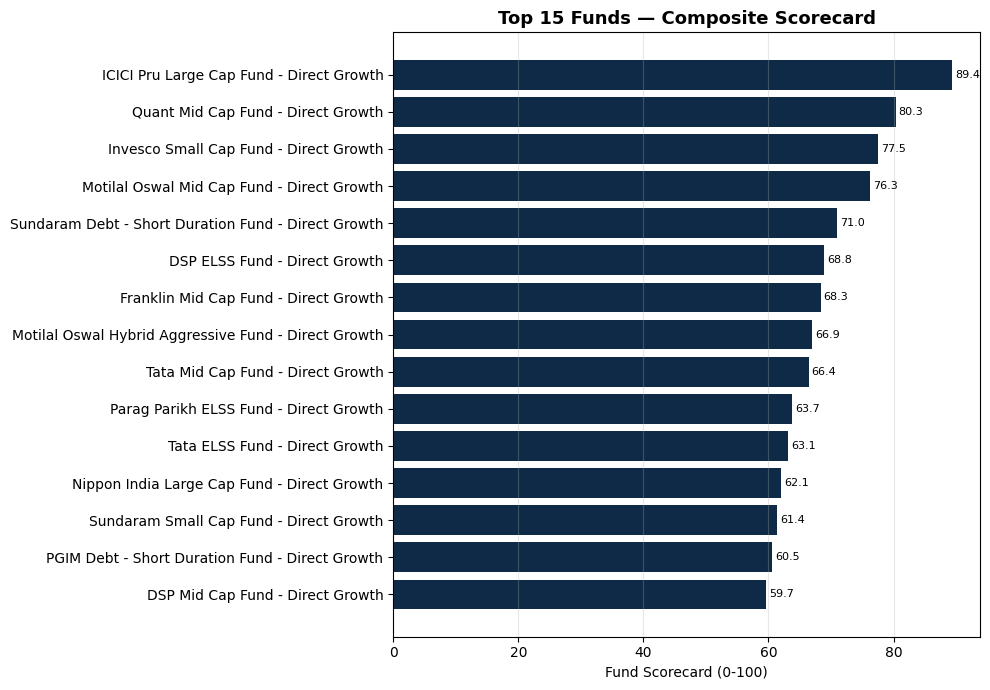

In [12]:
fig, ax = plt.subplots(figsize=(10,7))
top15 = scorecard.head(15).iloc[::-1]
bars = ax.barh(top15['fund_name'], top15['fund_scorecard'], color=COLORS[0])
ax.set_xlabel('Fund Scorecard (0-100)')
ax.set_title('Top 15 Funds — Composite Scorecard', fontsize=13, fontweight='bold')
for b, v in zip(bars, top15['fund_scorecard']):
    ax.text(v + 0.5, b.get_y() + b.get_height()/2, f'{v:.1f}', va='center', fontsize=8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.savefig('charts/03_scorecard_top15.png', dpi=200); plt.show()

## 9. Benchmark Comparison — Top 5 Funds vs Nifty 50 / Nifty 100 (3 years)
Plots the top-5 scorecard funds' cumulative growth of ₹100 against both benchmarks over the trailing 3 years, and computes **tracking error** = `std(fund_return − benchmark_return) × √252` against Nifty 100 for each of the 5.

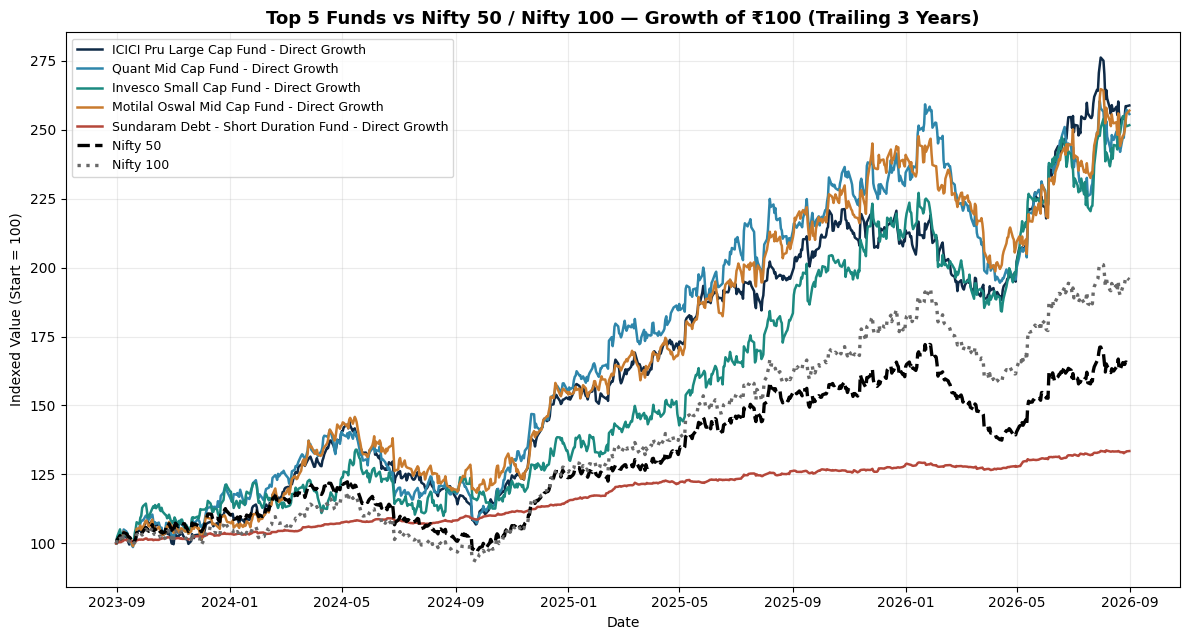

In [13]:
three_yr_start = last_date - pd.DateOffset(years=3)
top5_codes = scorecard.head(5).index.tolist()

nav_3y = nav_wide.loc[nav_wide.index >= three_yr_start, top5_codes]
bench_3y = bench.loc[bench.index >= three_yr_start]

nav_3y_indexed = nav_3y / nav_3y.iloc[0] * 100
bench_3y_indexed = bench_3y / bench_3y.iloc[0] * 100

fig, ax = plt.subplots(figsize=(12,6.5))
for i, code_ in enumerate(top5_codes):
    label = fund_master.loc[code_, 'fund_name']
    ax.plot(nav_3y_indexed.index, nav_3y_indexed[code_], label=label, linewidth=1.8, color=COLORS[i % len(COLORS)])

ax.plot(bench_3y_indexed.index, bench_3y_indexed['nifty50'], label='Nifty 50', linewidth=2.4,
        color='black', linestyle='--')
ax.plot(bench_3y_indexed.index, bench_3y_indexed['nifty100'], label='Nifty 100', linewidth=2.4,
        color='dimgrey', linestyle=':')

ax.set_title('Top 5 Funds vs Nifty 50 / Nifty 100 — Growth of ₹100 (Trailing 3 Years)',
              fontsize=13, fontweight='bold')
ax.set_ylabel('Indexed Value (Start = 100)'); ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=9, ncol=1)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('charts/04_benchmark_comparison_top5.png', dpi=200)
plt.savefig('outputs/benchmark_comparison_chart.png', dpi=200)
plt.show()

In [14]:
tracking_error_rows = []
bmk_3y_ret = bench_3y_indexed['nifty100'].pct_change().dropna()
for code_ in top5_codes:
    fund_ret_3y = nav_3y_indexed[code_].pct_change().dropna()
    common = fund_ret_3y.index.intersection(bmk_3y_ret.index)
    diff = fund_ret_3y.loc[common] - bmk_3y_ret.loc[common]
    te = diff.std() * np.sqrt(252)
    tracking_error_rows.append({
        'fund_name': fund_master.loc[code_, 'fund_name'],
        'tracking_error_vs_nifty100': te,
        '3y_cagr': cagr_table.loc[code_, 'cagr_3y'],
        'fund_scorecard': scorecard.loc[code_, 'fund_scorecard'],
    })
tracking_error_df = pd.DataFrame(tracking_error_rows).sort_values('tracking_error_vs_nifty100')
print("Tracking Error (vs Nifty 100), Top 5 scorecard funds:")
tracking_error_df

Tracking Error (vs Nifty 100), Top 5 scorecard funds:


,fund_name,tracking_error_vs_nifty100,3y_cagr,fund_scorecard
0,ICICI Pru Large Cap Fund - Direct Growth,0.1020,0.3728,89.3590
1,Quant Mid Cap Fund - Direct Growth,0.1157,0.3673,80.3205
3,Motilal Oswal Mid Cap Fund - Direct Growth,0.1213,0.3695,76.2821
4,Sundaram Debt - Short Duration Fund - Direct G...,0.1542,0.1010,71.0256
2,Invesco Small Cap Fund - Direct Growth,0.1696,0.3600,77.5000


## 10. Save Deliverables

In [15]:
scorecard_out = scorecard.reset_index().rename(columns={'index': 'amfi_code'})
scorecard_out.to_csv('outputs/fund_scorecard.csv', index=False)

alpha_beta_out = alpha_beta_df.reset_index().rename(columns={'index': 'amfi_code'})
alpha_beta_out.to_csv('outputs/alpha_beta.csv', index=False)

print(f"Saved outputs/fund_scorecard.csv  -> {scorecard_out.shape}")
print(f"Saved outputs/alpha_beta.csv      -> {alpha_beta_out.shape}")
print(f"Saved charts/*.png                -> 4 charts")
print(f"Saved outputs/benchmark_comparison_chart.png (deliverable copy)")

Saved outputs/fund_scorecard.csv  -> (40, 16)
Saved outputs/alpha_beta.csv      -> (40, 8)
Saved charts/*.png                -> 4 charts
Saved outputs/benchmark_comparison_chart.png (deliverable copy)


---
## Appendix: Real-data column expectations

Swap in the real files with these columns and every cell above reruns unchanged:
- **`data/nav_history.csv`**: `amfi_code, date, nav` (long format, one row per fund per trading day)
- **`data/fund_master.csv`**: indexed/joinable on `amfi_code`, with at least `fund_name, fund_house, category, expense_ratio`
- **`data/benchmark_index.csv`**: `date, nifty50, nifty100` (daily index levels)

All 8 task requirements are implemented above: daily returns + distribution validation (§2), CAGR 1/3/5y comparison table (§3), Sharpe ranked (§4), Sortino ranked (§5), Alpha/Beta via `scipy.stats.linregress` (§6), Max Drawdown + worst date range (§7), 0–100 Fund Scorecard with the exact specified weights (§8), and the top-5-vs-benchmark chart + tracking error (§9).